In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
gaia = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/gaia_edr3_g_14_pm_dr9.fits'))

mask = gaia['PHOT_G_MEAN_MAG']<12
print(np.sum(mask)/len(mask))
gaia = gaia[mask]

# Coefficients for EDR3
coeffs = dict(
    g = [-0.1125681175, 0.3506376997, 0.9082025788, -1.0078309266,
        -1.4212131445, 4.5685722177, -4.5719415419, 2.3816887292,
        -0.7162270722, 0.1247021438, -0.0114938710, 0.0003949585,
        0.0000051647],
    r = [0.1431278873, -0.2999797766, -0.0553379742, 0.1544273115,
        0.3068634689, -0.9499143903, 0.9769739362, -0.4926704528,
        0.1272539574, -0.0133178183, -0.0008153813, 0.0003094116,
        -0.0000198891],
    z = [0.5173814296, -1.0450176704, 0.1529797809, 0.1856005222,
        -0.2366580132, 0.1018331214, -0.0189673240, 0.0012988354])

bprp_min, bprp_max = -0.5, 4.7

for i, band in enumerate(['g', 'r', 'z']):
    mag = np.copy(gaia['PHOT_G_MEAN_MAG'])
    for order, c in enumerate(coeffs[band]):
        x = gaia['PHOT_BP_MEAN_MAG']-gaia['PHOT_RP_MEAN_MAG']
        x = np.clip(x, bprp_min, bprp_max)
        mag += c * (x)**order
    gaia['decam_mag_'+band] = mag
    
mask = (gaia['PHOT_BP_MEAN_MAG']==0) | (gaia['PHOT_RP_MEAN_MAG']==0)
for band in ['g', 'r', 'z']:
    gaia['decam_mag_'+band][mask] = np.nan

0.22808040302272004


In [4]:
tycho2 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/Tycho-2-dr9.fits'))

mask = tycho2['VTmag']<10
tycho2 = tycho2[mask]
print(len(tycho2))

126232


In [5]:
twomass = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/2mass_psc/2mass_psc_j_12-dr9.fits'))

mask = twomass['Jmag']<11
twomass = twomass[mask]
print(len(twomass))

1132120


In [6]:
gaia['RA2000'] = gaia['RA'] - 16 * gaia['PMRA'] * 1e-3/3600 / np.cos(np.radians(gaia['DEC']))
gaia['DEC2000'] = gaia['DEC'] - 16 * gaia['PMDEC'] * 1e-3/3600

Doubly matched objects = 353
Final matched objects = 124668


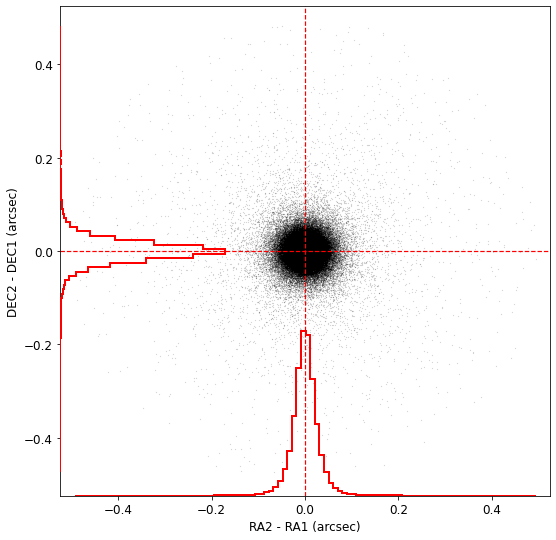

0.13565378622352603
0.987610114709424


In [7]:
sys.path.append(os.path.expanduser('~/git/Python/user_modules/'))
from match_coord import match_coord

idx1, idx2, d2d, d_ra, d_dec = match_coord(gaia['RA2000'], gaia['DEC2000'], tycho2['RA'], tycho2['DEC'], search_radius=0.5, plot_q=True)
print(len(idx1)/len(gaia))
print(len(idx1)/len(tycho2))

In [8]:
gaia = gaia[idx1]
tycho2 = tycho2[idx2]

Doubly matched objects = 4
Final matched objects = 123643


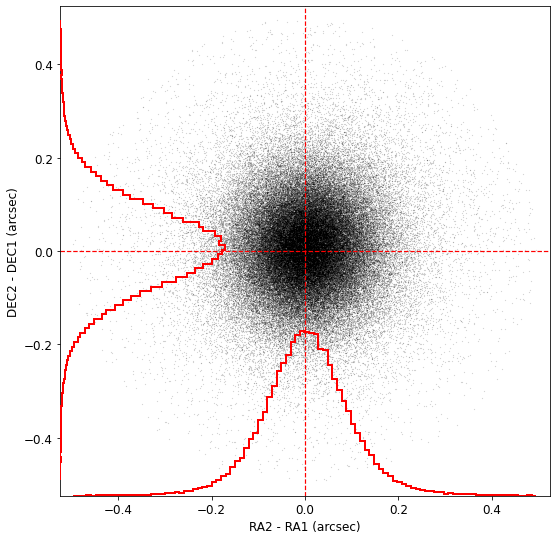

0.9917781628003979
0.1092136875949546


In [9]:
sys.path.append(os.path.expanduser('~/git/Python/user_modules/'))
from match_coord import match_coord

idx1, idx2, d2d, d_ra, d_dec = match_coord(gaia['RA2000'], gaia['DEC2000'], twomass['RA'], twomass['DEC'], search_radius=0.5, plot_q=True)
print(len(idx1)/len(gaia))
print(len(idx1)/len(twomass))

In [10]:
gaia = gaia[idx1]
tycho2 = tycho2[idx1]
twomass = twomass[idx2]

In [11]:
gaia[:1]

SOURCE_ID,RA,DEC,PHOT_G_MEAN_MAG,PHOT_G_MEAN_FLUX_OVER_ERROR,PHOT_BP_MEAN_MAG,PHOT_RP_MEAN_MAG,ASTROMETRIC_EXCESS_NOISE,PARALLAX,PARALLAX_ERROR,PMRA,PMRA_ERROR,PMDEC,PMDEC_ERROR,decam_mag_g,decam_mag_r,decam_mag_z,RA2000,DEC2000
int64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64
215820835313697408,89.98790268039771,53.16273782208863,9.56753,3892.6504,9.699432,9.320604,0.12422735,3.9001667,0.016970987,5.839834,0.017648973,-25.442123,0.015119232,9.658582,9.598768,9.71694,89.98785938948015,53.1628508982043


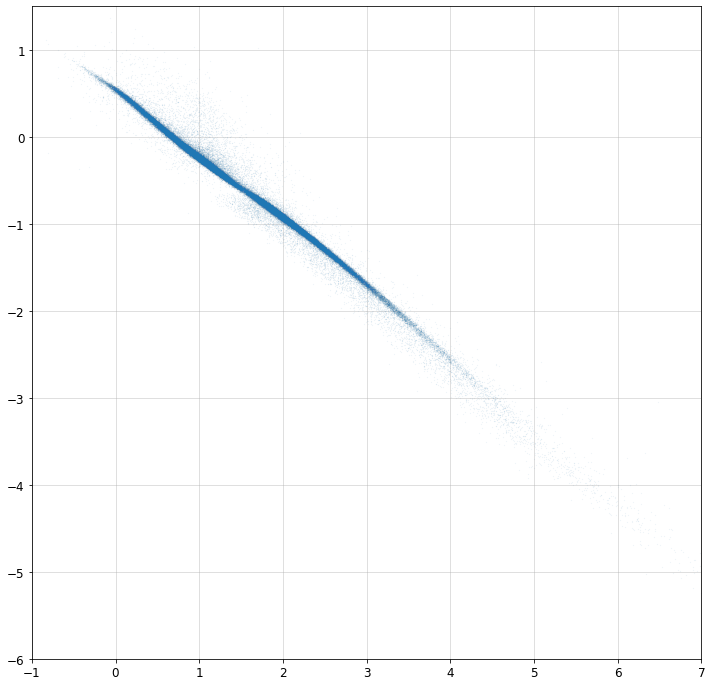

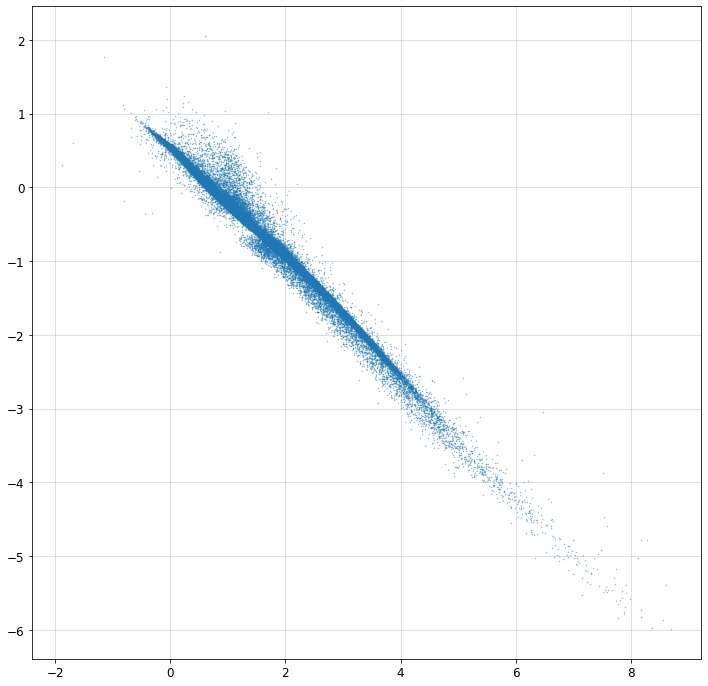

In [16]:
plt.figure(figsize=(12, 12))
plt.plot((tycho2['VTmag']-twomass['Jmag']), gaia['decam_mag_z'] - tycho2['VTmag'], '.', ms=0.1, alpha=0.5)
plt.axis([-1, 7, -6, 1.5])
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(12, 12))
plt.plot((tycho2['VTmag']-twomass['Jmag']), gaia['decam_mag_z'] - tycho2['VTmag'], '.', ms=1, alpha=0.5)
# plt.axis([-1, 7, -6, 1.5])
plt.grid(alpha=0.5)
plt.show()

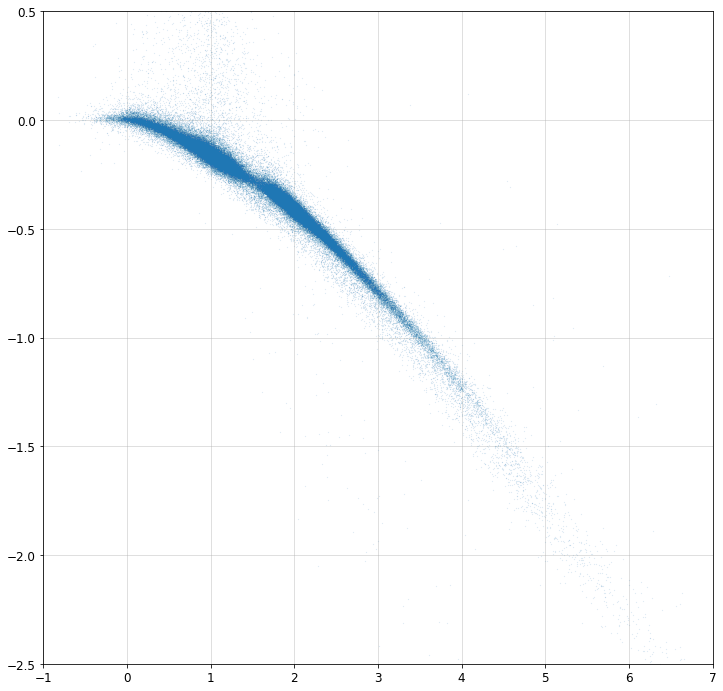

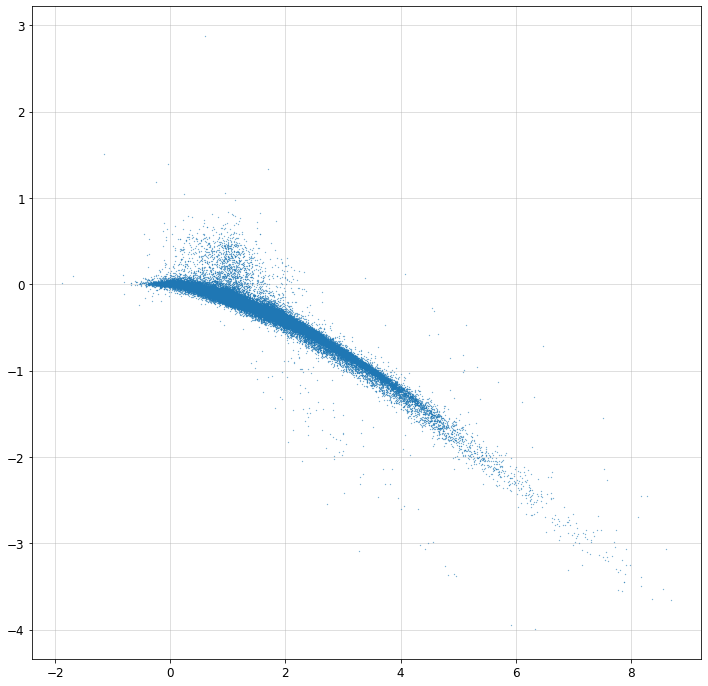

In [13]:
plt.figure(figsize=(12, 12))
plt.plot((tycho2['VTmag']-twomass['Jmag']), gaia['PHOT_G_MEAN_MAG'] - tycho2['VTmag'], '.', ms=0.2, alpha=0.5)
plt.axis([-1, 7, -2.5, 0.5])
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(12, 12))
plt.plot(tycho2['VTmag']-twomass['Jmag'], gaia['PHOT_G_MEAN_MAG'] - tycho2['VTmag'], '.', ms=0.5)
# plt.axis([-1, 7, -2.5, 0.5])
plt.grid(alpha=0.5)
plt.show()

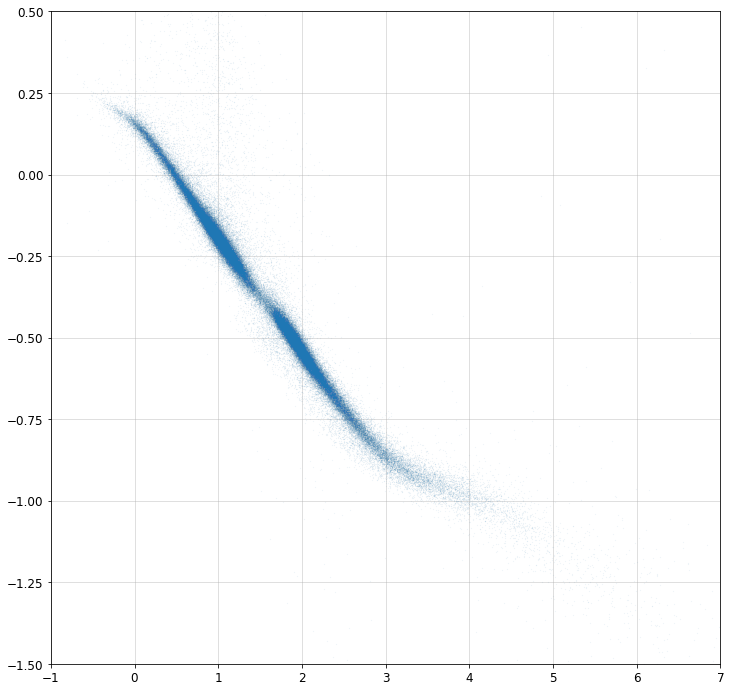

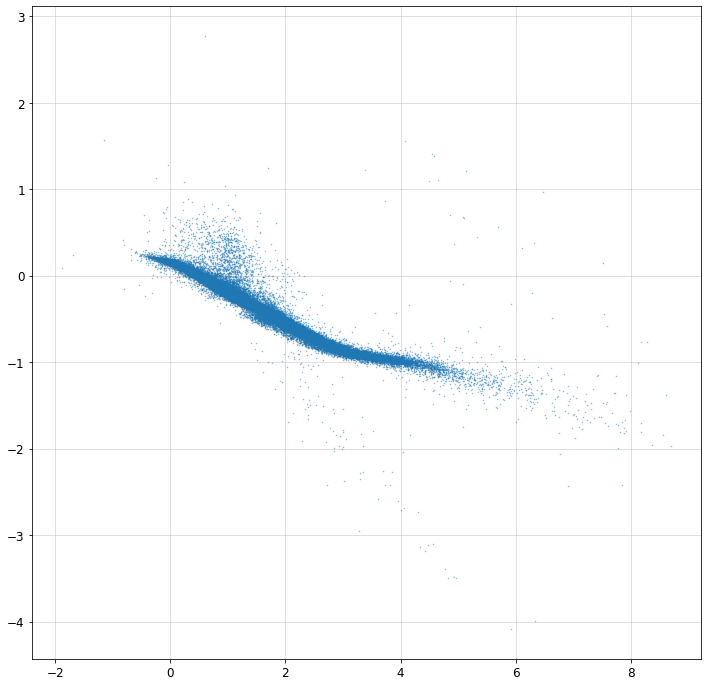

In [20]:
plt.figure(figsize=(12, 12))
plt.plot((tycho2['VTmag']-twomass['Jmag']), gaia['decam_mag_r'] - tycho2['VTmag'], '.', ms=0.1, alpha=0.5)
plt.axis([-1, 7, -1.5, 0.5])
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(12, 12))
plt.plot((tycho2['VTmag']-twomass['Jmag']), gaia['decam_mag_r'] - tycho2['VTmag'], '.', ms=1, alpha=0.5)
# plt.axis([-1, 7, -1.5, 0.5])
plt.grid(alpha=0.5)
plt.show()

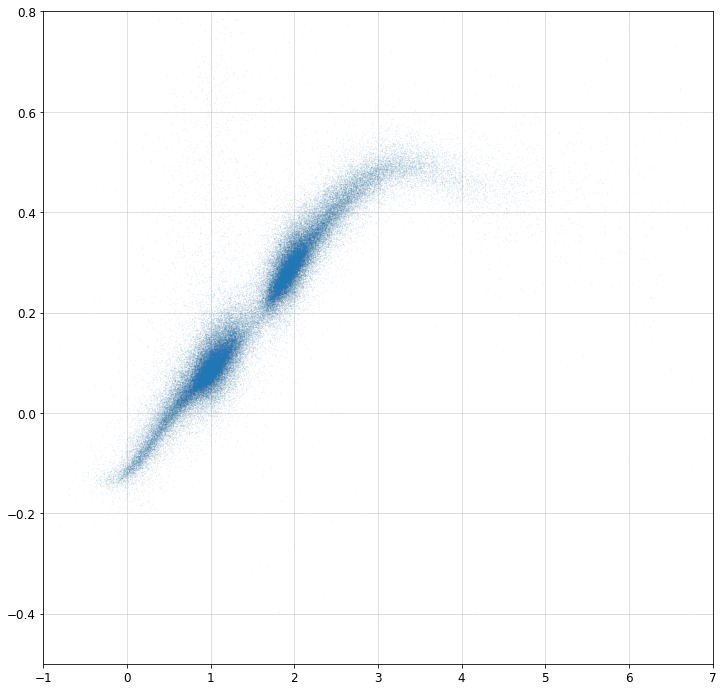

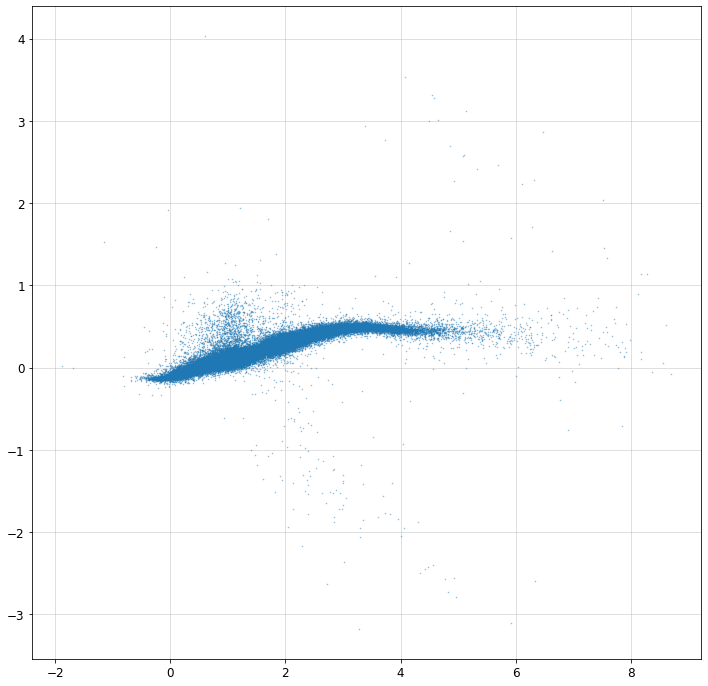

In [23]:
plt.figure(figsize=(12, 12))
plt.plot((tycho2['VTmag']-twomass['Jmag']), gaia['decam_mag_g'] - tycho2['VTmag'], '.', ms=0.1, alpha=0.5)
plt.axis([-1, 7, -0.5, 0.8])
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(12, 12))
plt.plot((tycho2['VTmag']-twomass['Jmag']), gaia['decam_mag_g'] - tycho2['VTmag'], '.', ms=1, alpha=0.5)
# plt.axis([-1, 7, -1.5, 0.5])
plt.grid(alpha=0.5)
plt.show()